# Rede Neural do Zero

## Objetivo
Construir uma **rede neural multicamadas (MLP)** do zero em Python, utilizando apenas bibliotecas básicas. Cada célula abaixo introduz um componente da arquitetura e em seguida sua implementação e execução.

## Bibliotecas utilizadas
- **NumPy**: operações com arrays e álgebra linear (única dependência externa)
- **math** (padrão Python): constantes como `e` para funções de ativação

## Estrutura do material
1. **Neurônio** – soma ponderada e ativação
2. **Camada** – conjunto de neurônios
3. **Forward propagation** – passagem dos dados pela rede
4. **Função de perda** – erro entre predição e alvo
5. **Backpropagation** – cálculo dos gradientes
6. **Atualização dos pesos** – gradiente descendente
7. **Treinamento completo** – loop de épocas e avaliação

---
## 1. Imports e dados de exemplo

Importamos apenas **NumPy** (e `math` da biblioteca padrão). Em seguida, criamos um conjunto de dados simples para classificação: o problema **XOR** (ou exclusivo), que não é linearmente separável e exige uma rede com camada oculta.

In [1]:
import numpy as np
import math

# Dados XOR: entradas (2 features) e saídas esperadas (0 ou 1)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float64)
y = np.array([[0], [1], [1], [0]], dtype=np.float64)

print("Entradas X (4 amostras, 2 features):")
print(X)
print("\nSaídas esperadas y:")
print(y)

Entradas X (4 amostras, 2 features):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Saídas esperadas y:
[[0.]
 [1.]
 [1.]
 [0.]]


---
## 2. O neurônio

Cada **neurônio** calcula:
1. **Soma ponderada**: $z = w_1 x_1 + w_2 x_2 + \ldots + b$ (pesos $w$, entradas $x$, bias $b$)
2. **Saída**: $a = \sigma(z)$, onde $\sigma$ é uma **função de ativação** (ex.: sigmoide)

A sigmoide mapeia qualquer valor para o intervalo $(0, 1)$. Fórmula centralizada:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [2]:
def sigmoid(z):
    """Função de ativação sigmoide: sigma(z) = 1 / (1 + e^(-z))."""
    z = np.clip(z, -500, 500)  # evita overflow
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    """Derivada da sigmoide em termos da saída a = sigmoid(z): d(sigma)/dz = a * (1 - a)."""
    return a * (1.0 - a)

# Exemplo: um neurônio com 2 entradas, pesos [0.5, -0.3], bias 0.1
x_exemplo = np.array([1.0, 0.5])
w_exemplo = np.array([0.5, -0.3])
b_exemplo = 0.1
z_exemplo = np.dot(w_exemplo, x_exemplo) + b_exemplo
a_exemplo = sigmoid(z_exemplo)
print(f"Entrada: {x_exemplo}, Pesos: {w_exemplo}, Bias: {b_exemplo}")
print(f"z = w·x + b = {z_exemplo:.4f}, a = sigmoid(z) = {a_exemplo:.4f}")

Entrada: [1.  0.5], Pesos: [ 0.5 -0.3], Bias: 0.1
z = w·x + b = 0.4500, a = sigmoid(z) = 0.6106


---
## 3. Uma camada (layer)

Uma **camada** é um conjunto de neurônios que recebem as **mesmas entradas** e produzem um vetor de saídas.  
- Entrada: vetor de tamanho `n_entrada`
- Saída: vetor de tamanho `n_neurônios`
- **Matriz de pesos** `W`: shape `(n_entrada, n_neurônios)` — cada coluna são os pesos de um neurônio
- **Vetor de bias** `b`: shape `(n_neurônios,)`  
Fórmula vetorizada (centralizada):

$$\mathbf{a} = \sigma(\mathbf{X} \mathbf{W} + \mathbf{b})$$

In [3]:
def forward_layer(X, W, b, activation=sigmoid):
    """
    Forward de uma camada: Z = X @ W + b, A = activation(Z).
    X: (n_amostras, n_entrada), W: (n_entrada, n_neurônios), b: (n_neurônios,)
    Retorna A e Z (guardamos Z para backprop).
    """
    Z = np.dot(X, W) + b
    A = activation(Z)
    return A, Z

# Exemplo: 4 amostras (X), 2 entradas, 3 neurônios na camada
np.random.seed(42)
n_entrada, n_neuronios = 2, 3
W_camada = np.random.randn(n_entrada, n_neuronios) * 0.5
b_camada = np.zeros(n_neuronios)
A_out, Z_out = forward_layer(X, W_camada, b_camada)
print("Saída da camada A (4 amostras x 3 neurônios):")
print(A_out)
print("\nZ (antes da ativação):")
print(Z_out)

Saída da camada A (4 amostras x 3 neurônios):
[[0.5        0.5        0.5       ]
 [0.68168255 0.47076421 0.47076626]
 [0.56177208 0.48272384 0.58026084]
 [0.7329951  0.45358184 0.55151055]]

Z (antes da ativação):
[[ 0.          0.          0.        ]
 [ 0.76151493 -0.11707669 -0.11706848]
 [ 0.24835708 -0.06913215  0.32384427]
 [ 1.009872   -0.18620884  0.20677579]]


---
## 4. Forward propagation (rede completa)

Uma rede com **uma camada oculta** e **uma camada de saída**:
- Camada 1: entrada (2) → oculta (4 neurônios) → ativação sigmoide
- Camada 2: oculta (4) → saída (1 neurônio) → sigmoide

Guardamos todas as **atividades (A)** e **pré-ativações (Z)** de cada camada para usar no backprop.

In [4]:
def forward_rede(X, params):
    """
    params: dict com W1, b1, W2, b2 (arquitetura 2 -> 4 -> 1).
    Retorna predição final A2 e cache (A1, Z1, A2, Z2) para backprop.
    """
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    A1, Z1 = forward_layer(X, W1, b1)
    A2, Z2 = forward_layer(A1, W2, b2)
    cache = {"X": X, "A1": A1, "Z1": Z1, "A2": A2, "Z2": Z2}
    return A2, cache

# Inicialização dos parâmetros (será usada no treino)
def init_params(n_entrada=2, n_oculta=4, n_saida=1, seed=42):
    np.random.seed(seed)
    W1 = np.random.randn(n_entrada, n_oculta) * 0.5
    b1 = np.zeros(n_oculta)
    W2 = np.random.randn(n_oculta, n_saida) * 0.5
    b2 = np.zeros(n_saida)
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

params = init_params()
pred, cache = forward_rede(X, params)
print("Predição da rede (4 amostras, 1 saída):")
print(pred)
print("\nCache (A1, Z1, A2, Z2) armazenado para backprop.")

Predição da rede (4 amostras, 1 saída):
[[0.44669943]
 [0.43029337]
 [0.42699871]
 [0.41263144]]

Cache (A1, Z1, A2, Z2) armazenado para backprop.


---
## 5. Função de perda (loss)

Medimos o erro entre a **predição** $\hat{y}$ e o **alvo** $y$. Para classificação binária com saída em $[0,1]$, usamos **entropia cruzada binária** (BCE):

$$\mathcal{L} = -\frac{1}{n} \sum_i \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]$$

Evitamos $\log(0)$ fazendo um clip nas predições.

In [5]:
def loss_bce(y_true, y_pred, eps=1e-15):
    """Entropia cruzada binária. y_true e y_pred: (n_amostras, 1)."""
    y_pred = np.clip(y_pred, eps, 1 - eps)
    n = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / n

# Exemplo com a predição atual da rede
loss_atual = loss_bce(y, pred)
print(f"Loss (BCE) com pesos aleatórios: {loss_atual:.4f}")
print("(Objetivo do treino: minimizar esse valor)")

Loss (BCE) com pesos aleatórios: 0.7046
(Objetivo do treino: minimizar esse valor)


---
## 6. Backpropagation

O **backpropagation** calcula os gradientes de $\mathcal{L}$ em relação a todos os pesos e biases, aplicando a **regra da cadeia** de trás para frente:

1. **Saída**: $dZ_2 = \hat{y} - y$ (derivada da BCE com sigmoide)
2. **Camada 2**: $dW_2 = A_1^T \, dZ_2$, $db_2 = \text{soma}(dZ_2)$, $dA_1 = dZ_2 \, W_2^T$
3. **Camada 1**: $dZ_1 = dA_1 \odot \sigma'(Z_1)$, depois $dW_1 = X^T \, dZ_1$, $db_1 = \text{soma}(dZ_1)$

Assim obtemos `grads["dW1"], grads["db1"], grads["dW2"], grads["db2"]`.

In [6]:
def backprop(params, cache, y_true):
    """Calcula gradientes da loss em relação a W1, b1, W2, b2."""
    X, A1, Z1, A2, Z2 = cache["X"], cache["A1"], cache["Z1"], cache["A2"], cache["Z2"]
    n = y_true.shape[0]
    # Saída: derivada da BCE + sigmoide => dZ2 = A2 - y
    dZ2 = A2 - y_true
    dW2 = np.dot(A1.T, dZ2) / n
    db2 = np.sum(dZ2, axis=0, keepdims=True) / n
    # Propagar para a camada oculta
    dA1 = np.dot(dZ2, params["W2"].T)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = np.dot(X.T, dZ1) / n
    db1 = np.sum(dZ1, axis=0, keepdims=True) / n
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

grads = backprop(params, cache, y)
print("Gradientes calculados:")
for k, v in grads.items():
    print(f"  {k}: shape {v.shape}")

Gradientes calculados:
  dW1: shape (2, 4)
  db1: shape (1, 4)
  dW2: shape (4, 1)
  db2: shape (1, 1)


---
## 7. Atualização dos pesos (gradiente descendente)

Atualizamos cada parâmetro na direção que **reduz** a loss:

$$W \leftarrow W - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$$

onde $\eta$ é a **taxa de aprendizado** (learning rate). O mesmo vale para os biases.

In [7]:
def update_params(params, grads, lr=0.5):
    """Atualiza pesos e biases: params = params - lr * grads."""
    params["W1"] -= lr * grads["dW1"]
    params["b1"] -= lr * grads["db1"].flatten()
    params["W2"] -= lr * grads["dW2"]
    params["b2"] -= lr * grads["db2"].flatten()
    return params

# Um passo de atualização
params = update_params(params, grads, lr=0.5)
pred_nova, cache_nova = forward_rede(X, params)
loss_nova = loss_bce(y, pred_nova)
print(f"Loss após um passo de gradiente: {loss_nova:.4f}")
print("Predição após 1 update:")
print(pred_nova)

Loss após um passo de gradiente: 0.6993
Predição após 1 update:
[[0.46591536]
 [0.45086525]
 [0.44788817]
 [0.43461355]]


---
## 8. Treinamento completo

Repetimos por várias **épocas**: para cada época, fazemos **forward** → **loss** → **backprop** → **update**. Ao final, a rede deve aprender a tabela XOR (saída ~0 para (0,0) e (1,1), ~1 para (0,1) e (1,0)).

In [8]:
def treinar(X, y, n_epocas=5000, lr=0.5, n_oculta=4, seed=42):
    """Treina a rede e retorna params e histórico da loss."""
    params = init_params(n_entrada=X.shape[1], n_oculta=n_oculta, n_saida=y.shape[1], seed=seed)
    historico_loss = []
    for epoca in range(n_epocas):
        pred, cache = forward_rede(X, params)
        loss = loss_bce(y, pred)
        historico_loss.append(loss)
        grads = backprop(params, cache, y)
        params = update_params(params, grads, lr=lr)
        if (epoca + 1) % 1000 == 0:
            print(f"Época {epoca + 1}: loss = {loss:.6f}")
    return params, historico_loss

params_final, historico = treinar(X, y, n_epocas=5000, lr=0.5)

Época 1000: loss = 0.594623
Época 2000: loss = 0.028354
Época 3000: loss = 0.010304
Época 4000: loss = 0.006146
Época 5000: loss = 0.004345


---
## 9. Avaliação e conclusão

Avaliamos a rede treinada: predição final e acurácia (classificação: pred &gt; 0.5 → 1, senão 0). Também exibimos a curva de loss ao longo das épocas (usando apenas `matplotlib` se disponível; caso contrário, apenas listamos os valores).

In [9]:
pred_final, _ = forward_rede(X, params_final)
pred_classe = (pred_final > 0.5).astype(np.float64)
acuracia = np.mean(pred_classe == y)
print("Entrada (X) -> Saída esperada (y) -> Predição (prob) -> Classe predita")
print("-" * 60)
for i in range(len(X)):
    print(f"  {X[i]} -> {y[i][0]:.0f} -> {pred_final[i][0]:.4f} -> {pred_classe[i][0]:.0f}")
print("-" * 60)
print(f"Acurácia: {acuracia * 100:.1f}%")
print("\nLoss nas últimas 10 épocas:", [round(historico[-10:][j], 6) for j in range(10)])

Entrada (X) -> Saída esperada (y) -> Predição (prob) -> Classe predita
------------------------------------------------------------
  [0. 0.] -> 0 -> 0.0059 -> 0
  [0. 1.] -> 1 -> 0.9960 -> 1
  [1. 0.] -> 1 -> 0.9960 -> 1
  [1. 1.] -> 0 -> 0.0035 -> 0
------------------------------------------------------------
Acurácia: 100.0%

Loss nas últimas 10 épocas: [np.float64(0.004357), np.float64(0.004355), np.float64(0.004354), np.float64(0.004353), np.float64(0.004352), np.float64(0.00435), np.float64(0.004349), np.float64(0.004348), np.float64(0.004346), np.float64(0.004345)]


---
## Resumo

Você implementou do zero:

| Componente | Função |
|------------|--------|
| Neurônio | `sigmoid`, soma ponderada |
| Camada | `forward_layer` |
| Rede | `forward_rede` + cache |
| Loss | `loss_bce` (entropia cruzada binária) |
| Gradientes | `backprop` (regra da cadeia) |
| Atualização | `update_params` (gradiente descendente) |
| Treino | `treinar` (loop de épocas) |

Com isso, a rede aprendeu a função **XOR** usando apenas **NumPy**. O mesmo esquema escala para mais camadas e mais neurônios; a ideia (forward → loss → backprop → update) permanece a mesma em redes profundas.

---
# Parte 2: Regressão com base de dados genérica (SQLite)

Usamos a mesma rede neural (MLP do zero) para **regressão**: prever uma variável contínua (**target**) a partir de quatro features. Os dados vêm do banco SQLite `data/regression_example.db` (tabela `regression_data`), gerado pelo script `data/gerar_dados_regressao.py`. A relação entre features e target é não linear, ideal para demonstrar a capacidade da rede.

## 10. Carregar dados do SQLite e preparar X, y

Conectamos ao banco `data/regression_example.db`, lemos a tabela `regression_data` (colunas: feature1–feature4, target) e montamos **X** (features) e **y** (target). Normalizamos com **min-max** para $[0, 1]$ e fazemos **divisão treino/teste** (80%/20%). Para gerar ou atualizar os dados: `python data/gerar_dados_regressao.py`.

In [10]:
import sqlite3
from pathlib import Path

# Banco genérico para regressão (gerado por data/gerar_dados_regressao.py)
PATH_DB = Path("data/regression_example.db")
conn = sqlite3.connect(PATH_DB)
cur = conn.cursor()
cur.execute("""
    SELECT feature1, feature2, feature3, feature4, target
    FROM regression_data
""")
dados = np.array(cur.fetchall(), dtype=np.float64)
conn.close()

# Features (4 colunas) e alvo (última coluna)
X_full = dados[:, :4]
y_full = dados[:, 4:5]   # shape (n, 1)

# Normalização min-max para [0, 1]
def minmax(X, x_min=None, x_max=None):
    if x_min is None:
        x_min, x_max = X.min(axis=0), X.max(axis=0)
    X_norm = (X - x_min) / (x_max - x_min + 1e-8)
    return X_norm, x_min, x_max

X_norm, X_min, X_max = minmax(X_full)
y_norm, y_min, y_max = minmax(y_full)

# Split treino (80%) / teste (20%)
n = len(X_norm)
np.random.seed(42)
idx = np.random.permutation(n)
n_train = int(0.8 * n)
i_train, i_test = idx[:n_train], idx[n_train:]
X_train, X_test = X_norm[i_train], X_norm[i_test]
y_train, y_test = y_norm[i_train], y_norm[i_test]

print("Dados carregados do SQLite:", X_full.shape[0], "amostras")
print("Features (após norm.):", X_train.shape[1], "| Alvo: target")
print("Treino:", X_train.shape[0], "| Teste:", X_test.shape[0])
print("y (original) min/max: {:.2f} / {:.2f}".format(y_min.item(), y_max.item()))

Dados carregados do SQLite: 400 amostras
Features (após norm.): 4 | Alvo: target
Treino: 320 | Teste: 80
y (original) min/max: -9.33 / 57.38


## 11. Regressão: saída linear e loss MSE

Para **regressão** a saída da rede deve ser um valor contínuo, não restrito a $(0,1)$. Por isso na **última camada** usamos ativação **linear** (identidade): $a = z$. A função de perda é o **erro quadrático médio** (MSE):

$$\mathcal{L} = \frac{1}{n} \sum_i (\hat{y}_i - y_i)^2$$

O gradiente em relação à saída é $\partial \mathcal{L}/\partial \hat{y} = (\hat{y} - y)$, e com ativação linear temos $dZ_2 = \hat{y} - y$ (mesma forma que já usamos no backprop).

In [11]:
def linear(z):
    """Ativação linear (identidade) para a camada de saída em regressão."""
    return z

def forward_rede_regression(X, params):
    """Forward com sigmoide na oculta e linear na saída (regressão)."""
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    A1, Z1 = forward_layer(X, W1, b1)           # oculta: sigmoide
    A2, Z2 = forward_layer(A1, W2, b2, linear)   # saída: linear
    cache = {"X": X, "A1": A1, "Z1": Z1, "A2": A2, "Z2": Z2}
    return A2, cache

def loss_mse(y_true, y_pred):
    """Erro quadrático médio."""
    return np.mean((y_pred - y_true) ** 2)

def backprop_regression(params, cache, y_true):
    """Backprop para MSE + saída linear: dZ2 = A2 - y."""
    X, A1, Z1, A2, Z2 = cache["X"], cache["A1"], cache["Z1"], cache["A2"], cache["Z2"]
    n = y_true.shape[0]
    dZ2 = A2 - y_true
    dW2 = np.dot(A1.T, dZ2) / n
    db2 = np.sum(dZ2, axis=0, keepdims=True) / n
    dA1 = np.dot(dZ2, params["W2"].T)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = np.dot(X.T, dZ1) / n
    db1 = np.sum(dZ1, axis=0, keepdims=True) / n
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

# Teste rápido: uma predição e o MSE
params_reg = init_params(n_entrada=4, n_oculta=8, n_saida=1, seed=42)
pred_reg, cache_reg = forward_rede_regression(X_train, params_reg)
print("MSE (treino, antes do treino):", round(loss_mse(y_train, pred_reg), 6))

MSE (treino, antes do treino): 2.177566


## 12. Treinamento com a base de regressão

Treinamos a rede com os dados de **treino** (X_train, y_train), usando MSE e backprop para regressão. Depois avaliamos no conjunto de **teste** e desnormalizamos as predições para a escala original do target.

In [15]:
def treinar_regressao(X, y, n_epocas=3000, lr=0.3, n_oculta=8, seed=42):
    """Treina a rede para regressão (MSE, saída linear)."""
    params = init_params(n_entrada=X.shape[1], n_oculta=n_oculta, n_saida=y.shape[1], seed=seed)
    historico = []
    for epoca in range(n_epocas):
        pred, cache = forward_rede_regression(X, params)
        loss = loss_mse(y, pred)
        historico.append(loss)
        grads = backprop_regression(params, cache, y)
        params = update_params(params, grads, lr=lr)
        if (epoca + 1) % 500 == 0:
            print(f"Época {epoca + 1}: MSE = {loss:.6f}")
    return params, historico

params_heat, hist_heat = treinar_regressao(X_train, y_train, n_epocas=5000, lr=0.1, n_oculta=8)

Época 500: MSE = 0.010354
Época 1000: MSE = 0.004112
Época 1500: MSE = 0.002640
Época 2000: MSE = 0.002296
Época 2500: MSE = 0.002206
Época 3000: MSE = 0.002172
Época 3500: MSE = 0.002150
Época 4000: MSE = 0.002131
Época 4500: MSE = 0.002114
Época 5000: MSE = 0.002098


In [16]:
# Predição no teste e desnormalização: y_real = y_norm * (y_max - y_min) + y_min
pred_test_norm, _ = forward_rede_regression(X_test, params_heat)
pred_test = pred_test_norm * (y_max - y_min) + y_min
y_test_real = y_test * (y_max - y_min) + y_min

mse_test = loss_mse(y_test, pred_test_norm)
rmse_test = np.sqrt(np.mean((pred_test - y_test_real) ** 2))
# R² = 1 - SS_res/SS_tot (coeficiente de determinação)
ss_res = np.sum((y_test_real - pred_test) ** 2)
ss_tot = np.sum((y_test_real - y_test_real.mean()) ** 2)
r2_test = 1 - (ss_res / (ss_tot + 1e-8))
print("Avaliação no conjunto de TESTE")
print("  MSE (escala normalizada):", round(mse_test, 6))
print("  RMSE (escala original do target):", round(rmse_test, 4))
print("  R² (coeficiente de determinação):", round(r2_test, 4))
print("\nAmostras (5 primeiras do teste):")
print("  y_real -> y_pred")
for i in range(min(5, len(y_test_real))):
    print(f"  {y_test_real[i][0]:.2f}  ->  {pred_test[i][0]:.2f}")

Avaliação no conjunto de TESTE
  MSE (escala normalizada): 0.002444
  RMSE (escala original do target): 3.2977
  R² (coeficiente de determinação): 0.9399

Amostras (5 primeiras do teste):
  y_real -> y_pred
  32.99  ->  35.87
  23.63  ->  27.19
  32.32  ->  31.68
  38.65  ->  38.92
  18.43  ->  20.44


## 13. Gráficos: real vs estimado e loss por épocas

**Esquerda:** dispersão do valor **real** (eixo x) vs **estimado** (eixo y) no conjunto de teste; a reta tracejada é a predição perfeita ($y = x$).  
**Direita:** evolução da **loss (MSE)** ao longo das épocas no treino.

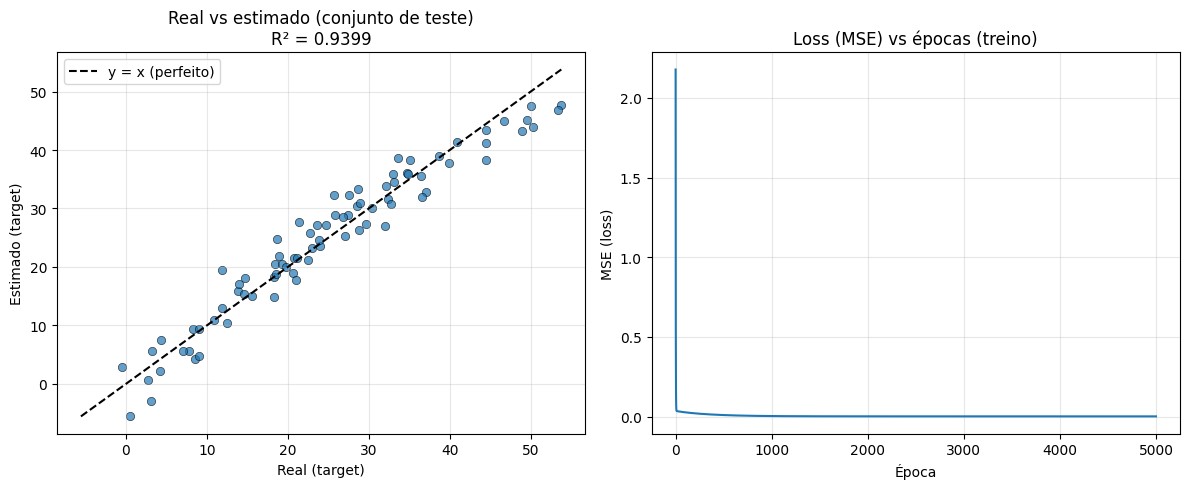

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Real vs estimado (teste)
y_r = y_test_real.flatten()
y_p = pred_test.flatten()
ax1.scatter(y_r, y_p, alpha=0.7, edgecolors="k", linewidths=0.5)
lim_min = min(y_r.min(), y_p.min())
lim_max = max(y_r.max(), y_p.max())
ax1.plot([lim_min, lim_max], [lim_min, lim_max], "k--", label="y = x (perfeito)")
ax1.set_xlabel("Real (target)")
ax1.set_ylabel("Estimado (target)")
ax1.set_title("Real vs estimado (conjunto de teste)\nR² = {:.4f}".format(r2_test))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss ao longo das épocas
ax2.plot(hist_heat, color="tab:blue")
ax2.set_xlabel("Época")
ax2.set_ylabel("MSE (loss)")
ax2.set_title("Loss (MSE) vs épocas (treino)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()